This project aims to evaluate instructor effectivness in an EdTech platform where instructors teach multiple batches and courses.The company wants to better understand instructor effectiveness using available data from learner outcomes, engagement, and feedback. So for that we need to analyze the data, define instructor effectiveness, and build an ML model to predict instructor effectiveness tiers. The dataset I have used here is instructor_effectiveness_dataset_2000_rows. This dataset contains columns batch_id, instructor_id, 'course_id', 'completion_rate','avg_score_improvement','avg_quiz_score', dropout_rate, avg_watch_time, assignment_submission_rate, forum_activity_rate, avg_feedback_score, feedback_response_rate.
In this project I have undergoes steps like Exploratory Data Analysis (EDA), Define instructor effectiveness, Aggregrate Batch Data to Instructor level, Build a Machine Learning Model, Evaluate the Model, Interpret the Results.

### Import Necessary Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('instructor_effectiveness_dataset_2000_rows.csv')

In [5]:
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [7]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [8]:
#Check whether is a missing values
df.isna().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

So, there is no missing values, so the data is already cleaned

In [10]:
df.shape

(2000, 12)

In [11]:
df.columns

Index(['batch_id', 'instructor_id', 'course_id', 'completion_rate',
       'avg_score_improvement', 'avg_quiz_score', 'dropout_rate',
       'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate',
       'avg_feedback_score', 'feedback_response_rate'],
      dtype='object')

# Step 1 : Exploratory Data Analysis (EDA)

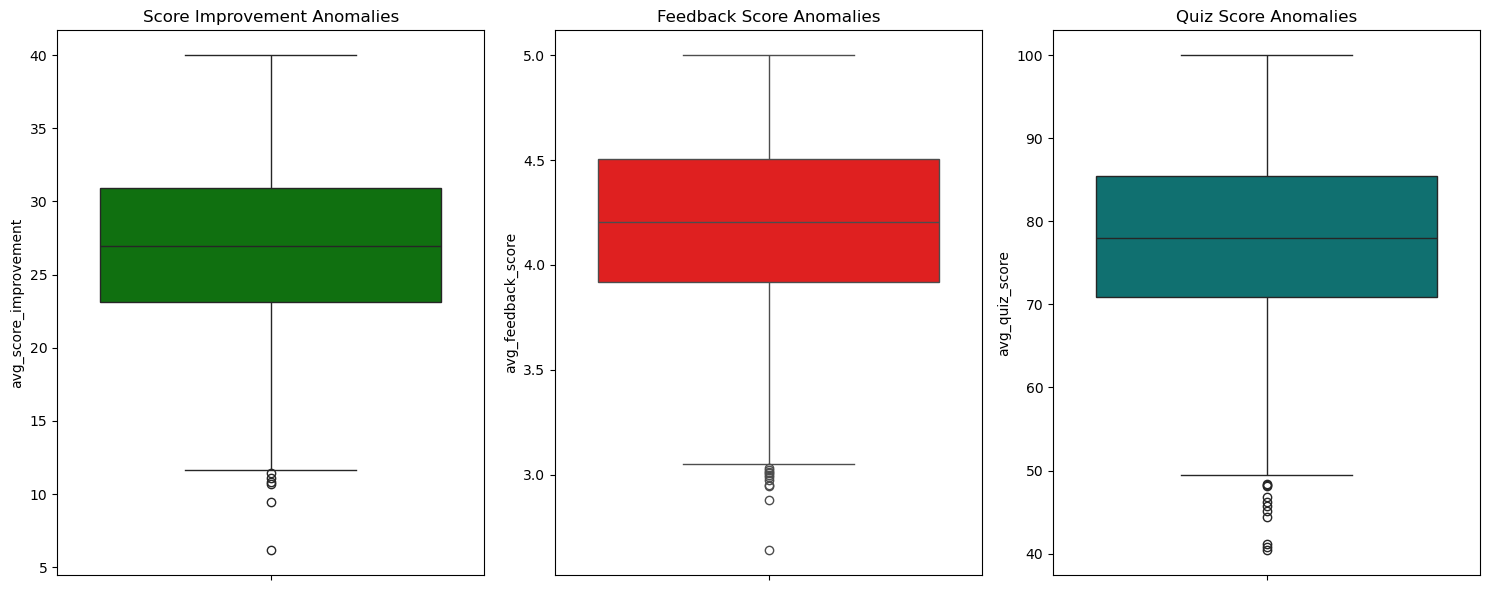

In [13]:
#Boxplot
plt.figure(figsize = (15,6))

#Score Improvement
plt.subplot(1,3,1)
sns.boxplot(y = 'avg_score_improvement', color = 'green', data = df)
plt.title('Score Improvement Anomalies')

#Feedback Anomaly Check
plt.subplot(1,3,2)
sns.boxplot(y = 'avg_feedback_score', color = 'red', data = df)
plt.title('Feedback Score Anomalies')

#Anomaly Check for Quiz Scores
plt.subplot(1,3,3)
sns.boxplot(y = 'avg_quiz_score', color = 'teal', data = df)
plt.title('Quiz Score Anomalies')

plt.tight_layout()
plt.show()

Boxplots help identify outlier batches where performance was unusually high or low. Identifying these are crucial because instructors teach multiple batches. We need to decide if an instructor's effectiveness should be based on their average performance or their consistency across all batches

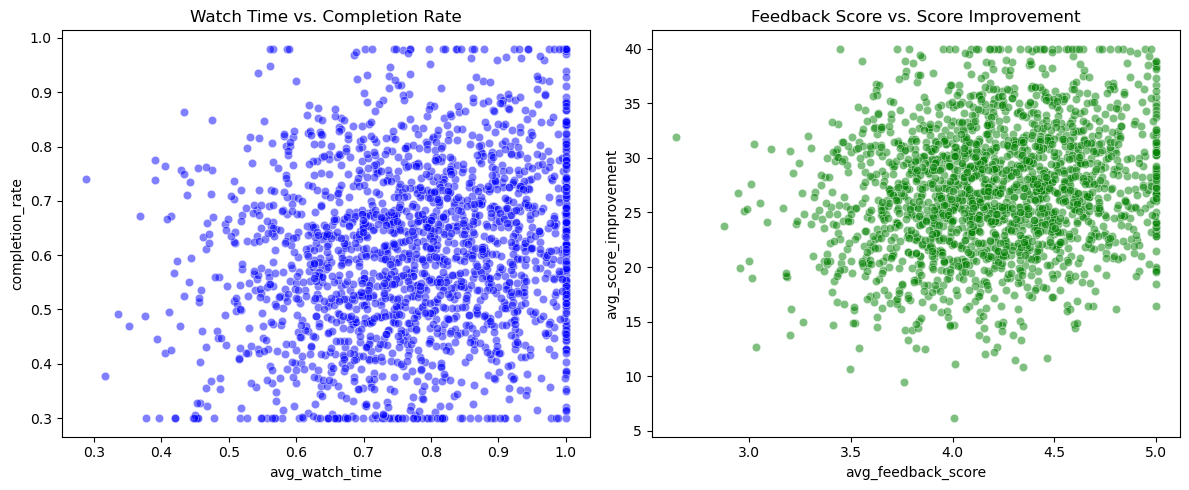

In [15]:
#Scatterplot
#Engagement and Outcome
plt.figure(figsize = (12,5))

#Watch Time vs Completion
plt.subplot(1,2,1)
sns.scatterplot(x = 'avg_watch_time', y = 'completion_rate', data = df, alpha = 0.5, color = 'blue')
plt.title('Watch Time vs. Completion Rate')

#Feedback vs Score Improvement
plt.subplot(1,2,2)
sns.scatterplot(x = 'avg_feedback_score', y = 'avg_score_improvement', data = df, alpha = 0.5, color = 'green')
plt.title('Feedback Score vs. Score Improvement')

plt.tight_layout()
plt.show()

Scatterplots help us visualize the direct relationship between two metrics, such as Average watch Time vs completion rate and Average Feedback score vs Average Score Improvement. As We can see the first scatterplot have more positive correlations than second plot. In first one, Students who watched entire video have high completion rates. but in the second plot even those give high feedback score, also get less score improvement in some cases . This helps us see if students who learn more also tend to like the instructor more, which confirms the multi-dimensional nature of effectiveness.

### Learner Outcomes

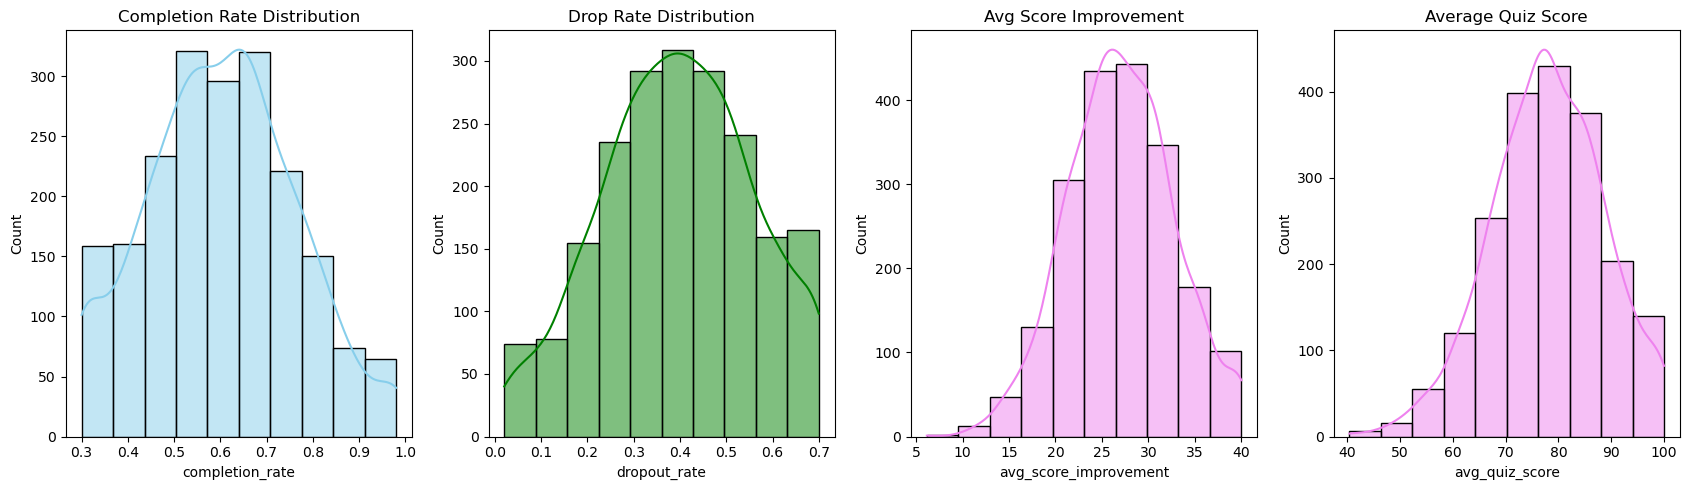

In [18]:
plt.figure(figsize = (17,5))

#Completion Rate Distribution
plt.subplot(1,4,1)
sns.histplot(x = 'completion_rate', data = df, kde = True, color = 'skyblue', bins = 10)
plt.title('Completion Rate Distribution')

#Dropout Rate
plt.subplot(1,4,2)
sns.histplot(df['dropout_rate'], kde = True, color = 'green', bins = 10)
plt.title('Drop Rate Distribution')

#Score Improvement
plt.subplot(1,4,3)
sns.histplot(x = 'avg_score_improvement', data = df, kde = True, color = 'violet', bins = 10)
plt.title('Avg Score Improvement')

plt.subplot(1,4,4)
sns.histplot(x = 'avg_quiz_score', data = df, kde = True, color = 'violet', bins = 10)
plt.title('Average Quiz Score')
plt.tight_layout()
plt.show()

The distributions for completion_rate, dropout_rate, avg_score_improvement, and avg_quiz_score show how well students are mastering the content. A high avg_score_improvement is a strong early indicator of an effective instructor, as it measures the actual knowledge gain from pre- to post-assessment.

### Engagement Metrics

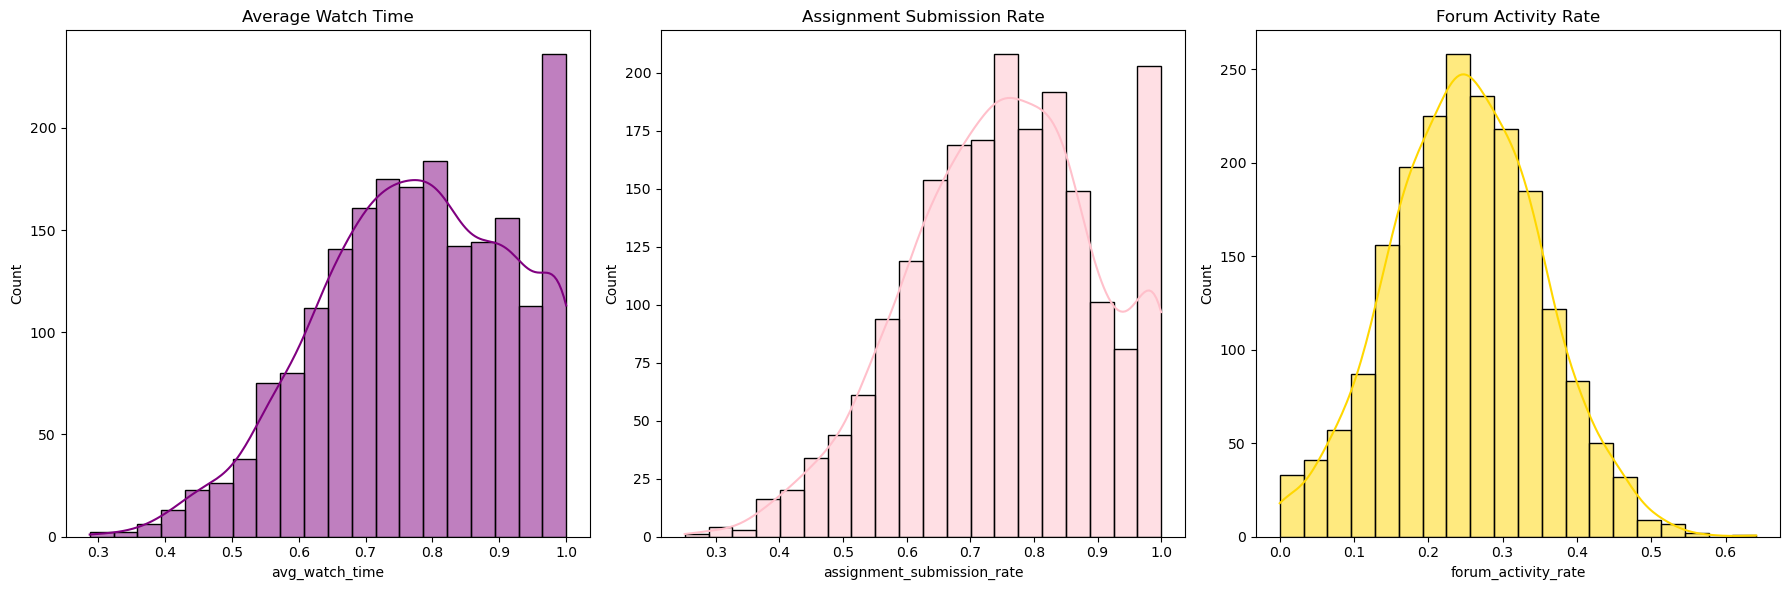

In [21]:
plt.figure(figsize = (18,6))

#Watch Time
plt.subplot(1,3,1)
sns.histplot(x = 'avg_watch_time', data = df, kde = True, color = 'purple', bins = 20)
plt.title('Average Watch Time')

#Assignment Submission
plt.subplot(1,3,2)
sns.histplot(x = 'assignment_submission_rate', data = df, kde = True, color = 'pink', bins = 20)
plt.title('Assignment Submission Rate')

#Forum Activity
plt.subplot(1,3,3)
sns.histplot(x = 'forum_activity_rate', data = df, kde = True, color = 'gold', bins = 20)
plt.title('Forum Activity Rate')


plt.tight_layout()
plt.show()

These plots illustrate how instructors keep learners involved through avg_watch_time, assignment_submission_rate, and forum_activity_rate. High engagement typically suggests the instructor is motivating, which is a key pillar of our effectiveness definition.

### Feedback Score

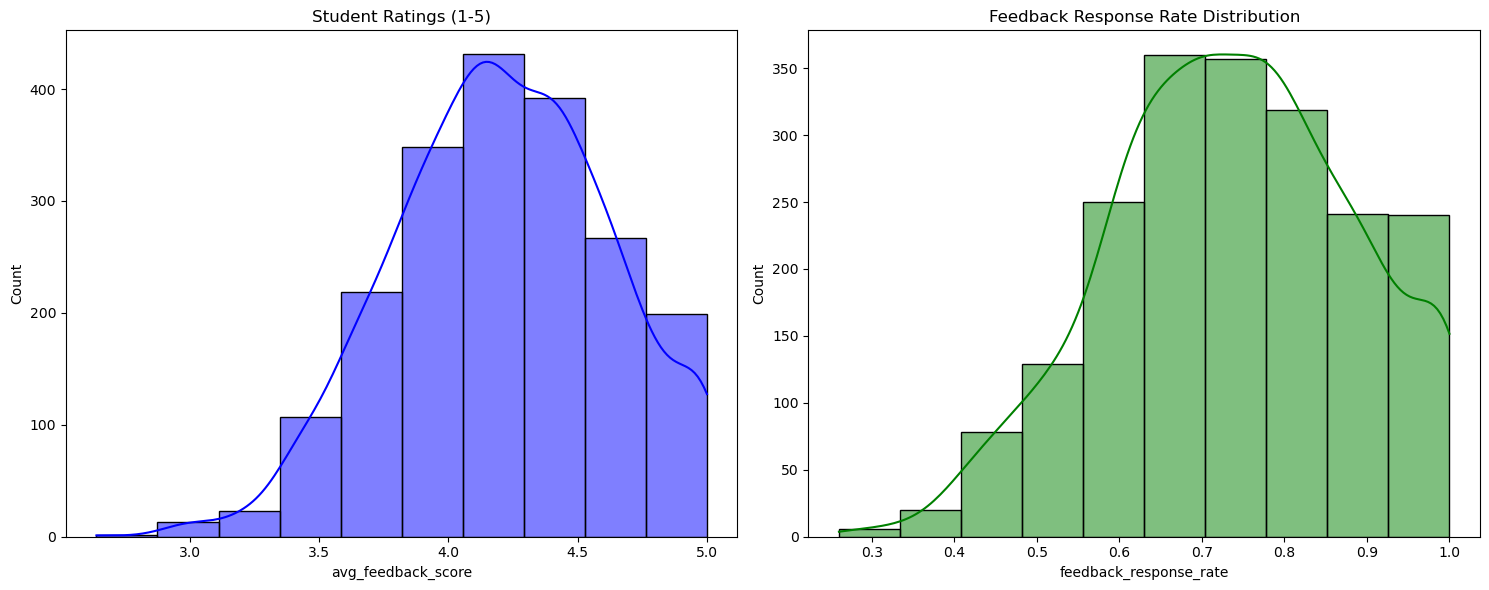

In [24]:
plt.figure(figsize = (15,6))

#Feedback Score
plt.subplot(1,2,1)
sns.histplot(x = 'avg_feedback_score', data = df, kde = True, color = 'blue', bins = 10)
plt.title('Student Ratings (1-5)')

#Feedback Response Rate
plt.subplot(1,2,2)
sns.histplot(x = 'feedback_response_rate', data = df, kde = True, color = 'green', bins = 10)
plt.title('Feedback Response Rate Distribution')


plt.tight_layout()
plt.show()

The avg_feedback_score (1-5) directly captures the learner's perception of the instructor. While these are often high, the feedback_response_rate is equally important because it shows how many students felt compelled to provide a rating in the first place.

### Correlation Heatmap

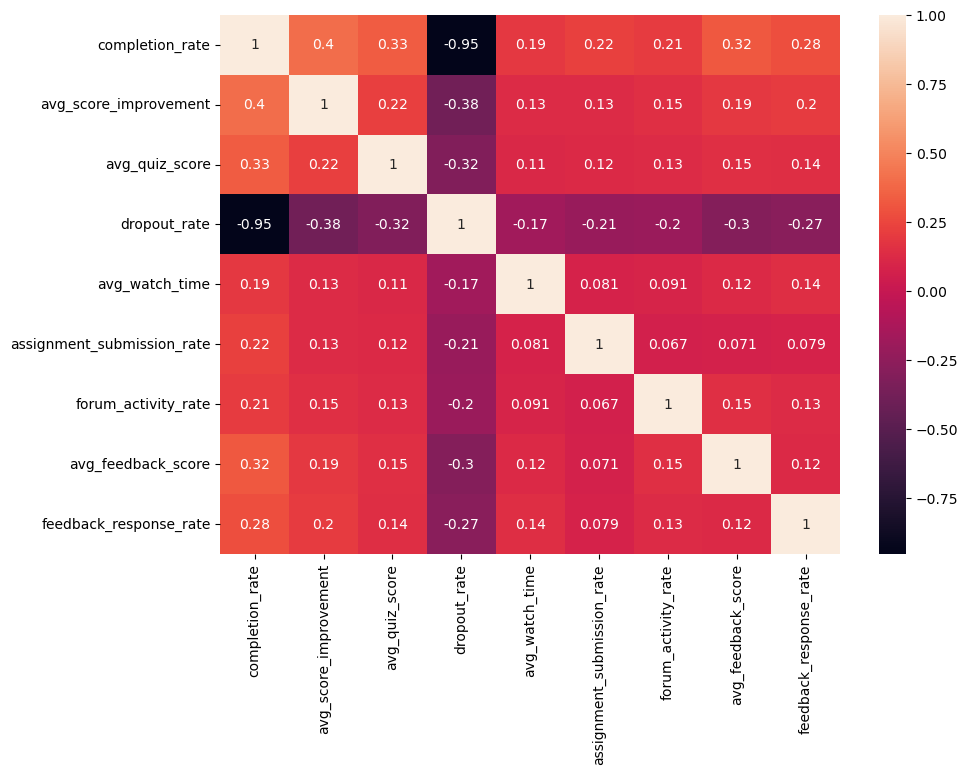

In [27]:
plt.figure(figsize = (10,7))
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = 'rocket')
plt.show()

The strong positive correlation between avg_watch_time and completion_rate suggests that instructor effectiveness is heavily tied to their ability to keep students engaged with the content.
I observed negative correlations with all dropout_rate. This confirms that higher instructor engagement is a direct defense against student churn.
Because avg_quiz_score, avg_watch_time, and avg_feedback_score all show positive trends with success metrics, I will use these as the primary pillars for defining the Instructor Effectiveness Score

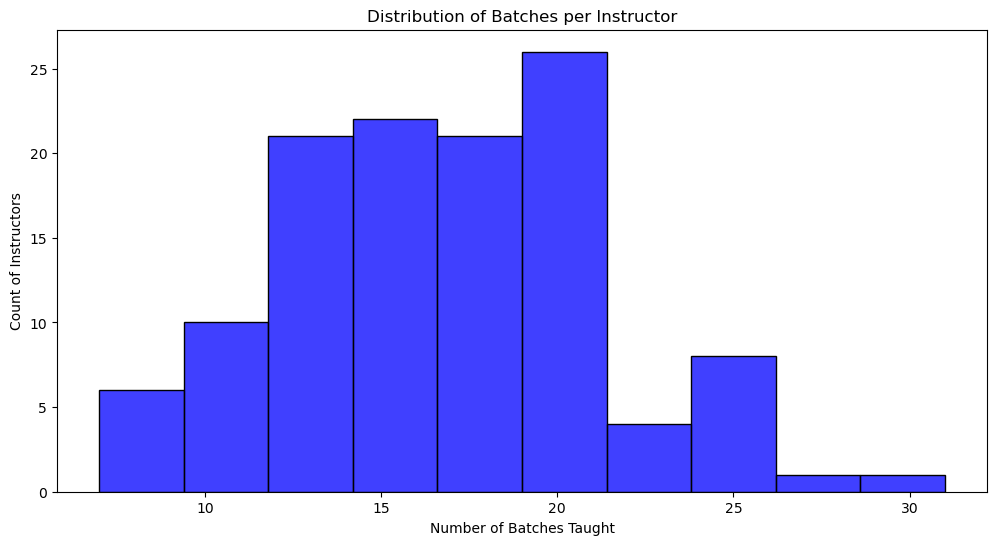

In [29]:
instructor_counts = df['instructor_id'].value_counts()

plt.figure(figsize = (12,6))
sns.histplot(instructor_counts, bins = 10, color = 'blue')
plt.title('Distribution of Batches per Instructor')
plt.xlabel('Number of Batches Taught')
plt.ylabel('Count of Instructors')
plt.show()

This plot shows the volume of data available per instructor. Some instructors have taught 10+ batches, while others have only one. This is a critical observation because my final model must account for the fact that we have more evidence for some instructors than others.

# Step 2 : Define Instructor Effectiveness

Instructor effectivenesss means how well on instructor teaches students.
from the data, I understand that effectiveness depends upon:
1. How students perform (marks,completion)
2. How students engage (watching videos, submitting assignments)
3. How student feel (feedback score)
so, I will combine these three to calculate effectiveness
But, Not all factors are equally important
* Learning outcome is most important : so higher weight
* Engagement is important : medium weight
* Feedback is important : medium weight

So, I assign Outcome = 0.4, Engagement = 0.3, Feedback = 0.3

In [33]:
#Normalize Feedback
df['normalized_feedback'] = df['avg_feedback_score']/5

Feedback score is from 1 to 5. I convert it to 0-1 so all values are on same scale.

In [35]:
#Create Outcome component

df['outcome_component'] = (df['completion_rate'] + (1 - df['dropout_rate']) + 
                           df['avg_score_improvement'] + df['avg_quiz_score']) / 4

Dropout Rate is inversed (1 - dropout_rate) because lower dropout means better performance

In [37]:
#Create Engagement Component

df['engagement_component'] = (df['avg_watch_time'] + df['assignment_submission_rate'] + df['forum_activity_rate'])/3

In [38]:
#Create Feedback Component

df['feedback_component'] = (df['avg_feedback_score'] + df['feedback_response_rate'])/2

In [39]:
#Final Effectiveness Score

df['effectiveness_score'] = (df['outcome_component'] * 0.4) + (df['engagement_component'] * 0.3) + (df['feedback_component'] * 0.3)

### Convert to tiers
To make results easy to understand, I convert score into : Low, Medium, High

In [41]:
df['effectiveness_tier'] = pd.qcut(df['effectiveness_score'], q = 3, labels = ['Low', 'Medium', 'High'])

# Step 3 : Aggregation

Since instructors teach multiple batches, I aggregate data to instructor level using mean

In [44]:
features = [
    'completion_rate', 'dropout_rate', 'avg_score_improvement',
    'avg_quiz_score', 'avg_watch_time',
    'assignment_submission_rate', 'forum_activity_rate',
    'avg_feedback_score', 'feedback_response_rate',
    'effectiveness_score'
]

In [45]:
instructor_df = df.groupby('instructor_id')[features].mean().reset_index()

In [46]:
tier_map = df.groupby('instructor_id')['effectiveness_tier'].agg(lambda x : x.mode()[0]).reset_index()

instructor_df = instructor_df.merge(tier_map, on = 'instructor_id')

I used mean as aggregate function for numerical features as we need average of it and use mode for effective tier because since we need most frequent one. For instructor with large batches, using mean is very stable. It will give accurate effectiveness. but for instructors with few batches using mean is more sensitive. if few students are unmotivated then instructor's score will look lower than actual one

### Feature Selection and Scaling

In [49]:
X = instructor_df.drop(['instructor_id', 'effectiveness_tier'], axis = 1)
y = instructor_df['effectiveness_tier']

In [50]:
#Scaling

from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()

In [52]:
xcolumns = X.columns

In [53]:
X = scaler.fit_transform(X)

In [54]:
X = pd.DataFrame(X, columns = xcolumns)
X.head()

,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score
0,-0.446321,0.594713,-0.135341,0.209060,-0.195485,-0.416368,-0.268021,0.070167,-0.650481,0.049775
1,0.975659,-1.160280,0.949569,0.756586,1.267054,0.391625,1.019980,0.751062,0.800025,0.901957
2,1.261385,-1.257429,0.891572,0.728357,0.876011,0.480295,1.193624,1.332868,1.250575,0.891437
3,-1.096973,1.197011,-1.283244,-0.026369,0.353734,0.118153,-0.643239,-0.698096,-0.219256,-0.565140
4,1.955701,-1.957346,1.695175,1.546119,1.465822,2.135972,2.172772,-0.012601,0.797729,1.686911


### Train Test Split

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

# Step 4 : Build a Machine Learning Model

This is a classification problem where goal is to predict instructor effectiveness tier ('Low', 'Medium', 'High')
1. I selected Random Forest Classifier because :
2. It handles non-linear relationships as well.
3. It reduces overfitting compared to single decision tree
4. It provides feature importance for interpretation

In [60]:
from sklearn.ensemble import RandomForestClassifier

In [61]:
model = RandomForestClassifier()

In [62]:
model.fit(X_train,y_train)

RandomForestClassifier()

In [63]:
model.score(X_train,y_train)

1.0

In [64]:
y_pred = model.predict(X_test)

# Step 5 : Evaluation Metrics

I use multiple evaluation metrics to assess model performance:
1. Accuracy to measure overall correctness
2. Precision to measure how many predicted label are correct
3. Recall to measure how well the model identifies each class.
4. F1 score to balance precision and recall

In [67]:
from sklearn import metrics

In [68]:
rf_accuracy = metrics.accuracy_score(y_test,y_pred)
print(f'Accuracy score of this model : {rf_accuracy}')

Accuracy score of this model : 0.75


In [69]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        High       0.86      0.86      0.86         7
         Low       0.86      0.67      0.75         9
      Medium       0.60      0.75      0.67         8

    accuracy                           0.75        24
   macro avg       0.77      0.76      0.76        24
weighted avg       0.77      0.75      0.75        24



### Confusion Matrix

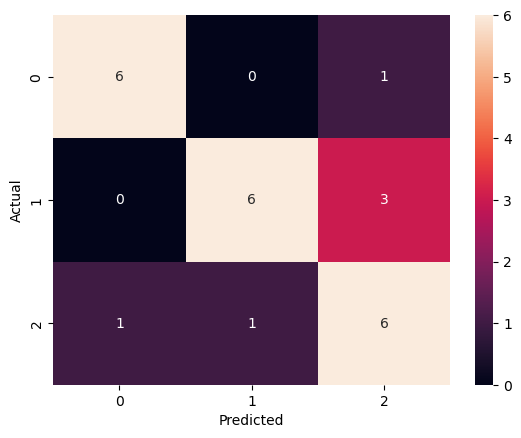

In [71]:
sns.heatmap(metrics.confusion_matrix(y_test,y_pred),annot = True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

There is a trade-off between precision and recall
1. Higher precision means fewer false positives.
2. Higher recall means False negatives

Recall is more important in this context because missing a highly effective instructor (false negative) could lead to poor decision-making. It is better to correctly identify all effective instructors, even if it slightly increases false positives.

In [73]:
#Checking class imbalance
print(y.value_counts())

effectiveness_tier
Low       48
Medium    38
High      34
Name: count, dtype: int64


The dataset shows a relatively balanced distribution across effectiveness tiers, with counts of 48 (Low), 38 (Medium), and 34 (High).
Although there is slight variation, it is not severe enough to significantly impact model performance. Therefore, accuracy remains a useful metric, while precision, recall, and F1-score provide additional insights.

# Step 6 : Interpret the results

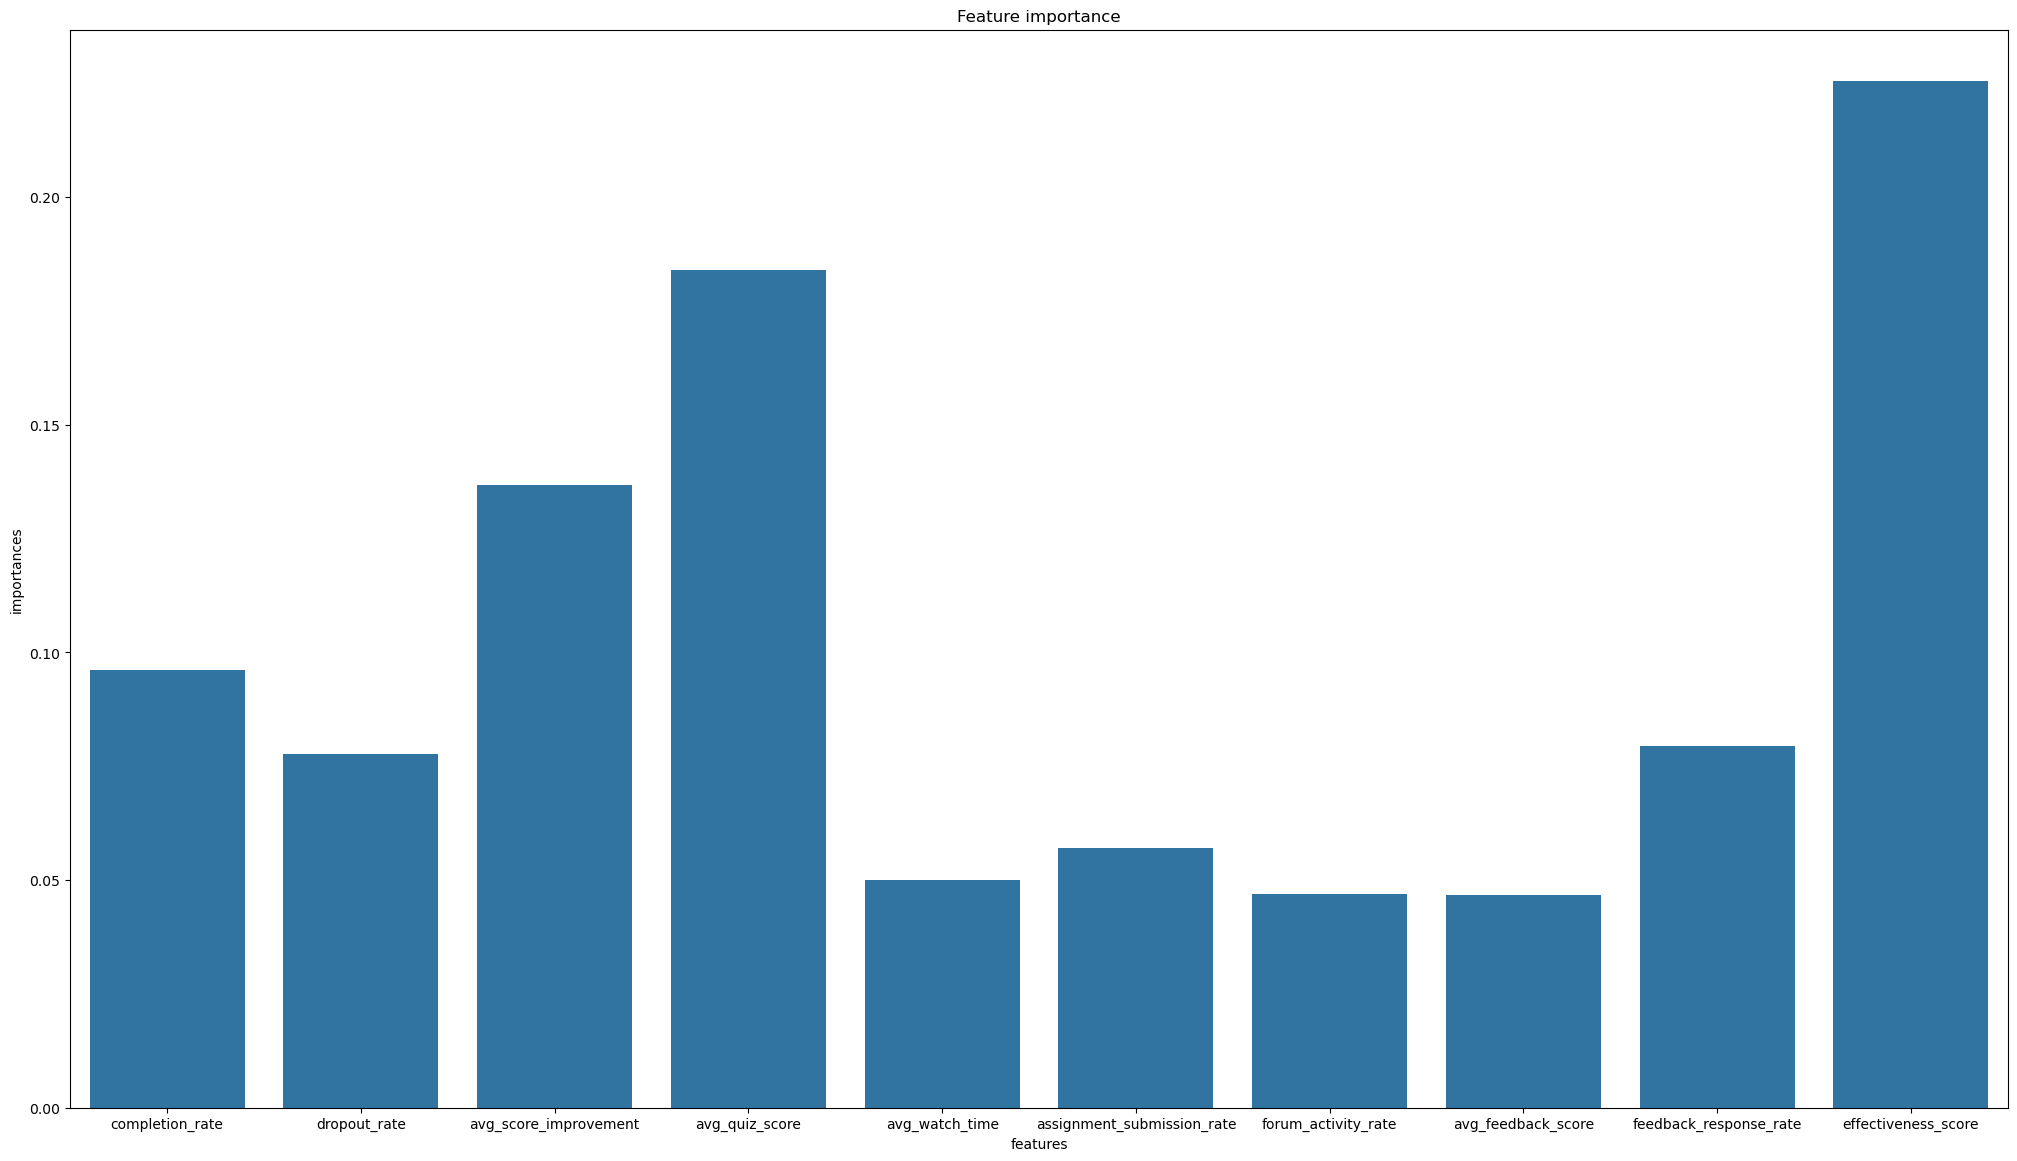

In [76]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize = (25,14))
sns.barplot(x = features, y = importances)
plt.title('Feature importance')
plt.xlabel('features')
plt.ylabel('importances')
plt.show()

The above plot shows which features are most important in predicting instructor effectiveness.
The most important features are completion rate, feedback score, and engagement metrics like watch time and assignment submission.

This means instructors are more effective when students complete the course, actively participate, and give good feedback.In simple terms, a good instructor is one who keeps students engaged, helps them complete the course, and receives positive feedback.

These insights can help the company identify top instructors, improve teaching quality, and provide support to low-performing instructors.

1) Which features most influenced instructor effectiveness, and why?

* When I looked at my heatmap, I looked for which columns had the strongest positive or negative correlations with each other. I noticed that Average Feedback Score, Average quiz time, Average watch time and Completion Rate were very strongly linked to student success. Later, when I built my Effectiveness Score using a weighted average, these features became the most important ones of the result. So, the heatmap showed me which data points were the most reliable to use for my final calculation.

2. Which variables could be misleading or confounded?

* I think Dropout Rate and Course ID could be misleading. For example, a very hard course (like Advanced AI) might have a naturally higher dropout rate regardless of how good the instructor is. If I just look at the numbers without considering the course difficulty, I might unfairly label a great instructor as Average just because their subject is tough.

3. How could this model fail in real-world usage?
   
* This model might fail if it's used on a brand-new instructor who hasn't taught many batches yet. Since my code aggregates data by instructor_id, an instructor with only one batch might get a skewed score. Also, if the platform changes how Feedback is collected, the model's old weights won't be accurate anymore. It treats all courses the same, but teaching a 5-student batch is very different from a 100-student batch.

4) What additional data would you want to improve this analysis?

* I would want to see the actual text comments from students, not just a 1 to 5 star rating. I would use use Sentiment Analysis on those comments. For example, a student might give a low score because the course material was hard, but say the instructor was amazing. Right now, my model can't tell the difference between a bad course and a bad instructor. Text data would help fix that. Also Checking out Student background and skills.

 5 Should model be used for instructor performance evaluation? Why or Why not?

* I don't think this model should be the only way to judge an instructor. As I found in my analysis, the effectiveness score is based on weights I chose manually (like 0.3 for enagagement metrics, feedback metrics and 0.4 for learning outcome). Someone else might choose different weights and get different results. It’s a good tool to see who might need help, but a human should always look at the context before making a final decision on an instructor's performance.